In [ ]:
import pandas as pd

df = pd.read_csv("smart_home_energy_consumption_large.csv")
print(df.head())
print(df.shape)


   Home ID Appliance Type  Energy Consumption (kWh)   Time        Date  \
0       94         Fridge                      0.20  21:12  2023-12-02   
1      435           Oven                      0.23  20:11  2023-08-06   
2      466     Dishwasher                      0.32  06:39  2023-11-21   
3      496         Heater                      3.92  21:56  2023-01-21   
4      137      Microwave                      0.44  04:31  2023-08-26   

   Outdoor Temperature (°C)  Season  Household Size  
0                      -1.0    Fall               2  
1                      31.1  Summer               5  
2                      21.3    Fall               3  
3                      -4.2  Winter               1  
4                      34.5  Summer               5  
(100000, 8)


In [ ]:
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
print(df[["Date","Time","Datetime"]].head())


         Date   Time            Datetime
0  2023-12-02  21:12 2023-12-02 21:12:00
1  2023-08-06  20:11 2023-08-06 20:11:00
2  2023-11-21  06:39 2023-11-21 06:39:00
3  2023-01-21  21:56 2023-01-21 21:56:00
4  2023-08-26  04:31 2023-08-26 04:31:00


In [ ]:
df["hour"] = df["Datetime"].dt.hour
df["dayofweek"] = df["Datetime"].dt.dayofweek
df["month"] = df["Datetime"].dt.month


In [ ]:
X = df[["Home ID", "Appliance Type", "Outdoor Temperature (°C)", "Season", "Household Size",
        "hour", "dayofweek", "month"]]

y = df["Energy Consumption (kWh)"]


In [ ]:
X = pd.get_dummies(X, columns=["Appliance Type", "Season"], drop_first=True)
print(X.head())


   Home ID  Outdoor Temperature (°C)  Household Size  hour  dayofweek  month  \
0       94                      -1.0               2    21          5     12   
1      435                      31.1               5    20          6      8   
2      466                      21.3               3     6          1     11   
3      496                      -4.2               1    21          5      1   
4      137                      34.5               5     4          5      8   

   Appliance Type_Computer  Appliance Type_Dishwasher  Appliance Type_Fridge  \
0                    False                      False                   True   
1                    False                      False                  False   
2                    False                       True                  False   
3                    False                      False                  False   
4                    False                      False                  False   

   Appliance Type_Heater  Appliance Ty

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)


MAE: 0.48118279999999997


In [ ]:
one = X_test.iloc[[0]]
pred = model.predict(one)[0]
actual = y_test.iloc[one.index[0]]

print("Predicted kWh:", pred)
print("Actual kWh:", actual)
print("Absolute error:", abs(pred - actual))


IndexError: single positional indexer is out-of-bounds

In [ ]:
one = X_test.iloc[[0]]
pred = model.predict(one)[0]
actual = y_test.loc[one.index[0]]

print("Predicted kWh:", pred)
print("Actual kWh:", actual)
print("Absolute error:", abs(pred - actual))


Predicted kWh: 0.9810500000000006
Actual kWh: 1.58
Absolute error: 0.5989499999999994


In [ ]:
import joblib

joblib.dump(model, "smart_home_energy_model.pkl")
print("Saved: smart_home_energy_model.pkl")


Saved: smart_home_energy_model.pkl


In [ ]:
import joblib

joblib.dump(model, "smart_home_energy_model.pkl")
joblib.dump(list(X.columns), "smart_home_energy_columns.pkl")

print("Saved model + columns")


Saved model + columns


In [ ]:
import numpy as np
import pandas as pd

cols = joblib.load("smart_home_energy_columns.pkl")

def predict_kwh(home_id, appliance_type, outdoor_temp, season, household_size, hour, dayofweek, month):
    row = pd.DataFrame([{
        "Home ID": home_id,
        "Appliance Type": appliance_type,
        "Outdoor Temperature (°C)": outdoor_temp,
        "Season": season,
        "Household Size": household_size,
        "hour": hour,
        "dayofweek": dayofweek,
        "month": month
    }])
    row = pd.get_dummies(row, columns=["Appliance Type", "Season"], drop_first=True)

    # add missing columns
    for c in cols:
        if c not in row.columns:
            row[c] = 0
    row = row[cols]  # same order as training

    return model.predict(row)[0]

print("Example prediction:", predict_kwh(10, "TV", 25.0, "Summer", 3, 20, 5, 7))


Example prediction: 3.4500499999999983


In [ ]:
# Test 5 random real records from your test set
for i in range(5):
    one = X_test.sample(1, random_state=42+i)
    pred = model.predict(one)[0]
    actual = y_test.loc[one.index[0]]
    print("Pred:", pred, "Actual:", actual, "AbsErr:", abs(pred-actual))


Pred: 1.0862000000000007 Actual: 0.47 AbsErr: 0.6162000000000007
Pred: 1.2285999999999988 Actual: 0.69 AbsErr: 0.5385999999999989
Pred: 0.9886 Actual: 1.71 AbsErr: 0.7213999999999999
Pred: 1.426650000000001 Actual: 0.7 AbsErr: 0.7266500000000011
Pred: 0.8358999999999986 Actual: 0.96 AbsErr: 0.12410000000000132


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))


MAE: 0.48118279999999997
R2: 0.7471801654097701


/tmp/ipython-input-620/1469983024.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.set_index("Datetime")["Energy Consumption (kWh)"].resample("H").mean().plot(figsize=(12,4))


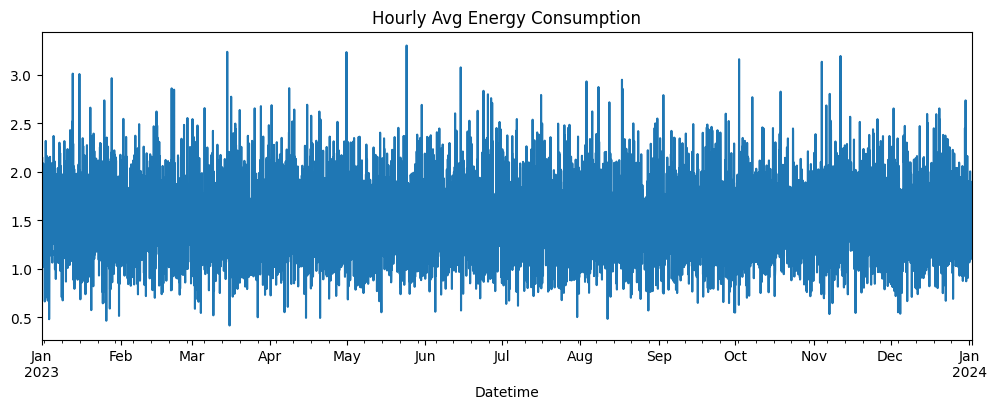

In [ ]:
import matplotlib.pyplot as plt

df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
df = df.dropna(subset=["Datetime"])

df.set_index("Datetime")["Energy Consumption (kWh)"].resample("H").mean().plot(figsize=(12,4))
plt.title("Hourly Avg Energy Consumption")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlp = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False works with one-hot data
    ("model", MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500, random_state=42))
])

mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)
print("MLP MAE:", mean_absolute_error(y_test, pred))


MLP MAE: 0.4843669960942637


In [ ]:
import joblib

joblib.dump(mlp, "energy_forecast_mlp.pkl")
joblib.dump(list(X.columns), "energy_forecast_columns.pkl")
print("Saved: energy_forecast_mlp.pkl and energy_forecast_columns.pkl")


Saved: energy_forecast_mlp.pkl and energy_forecast_columns.pkl
